In [1]:
import pandas as pd
import glob
import os
import scanpy as sc
from cellphonedb.utils import db_utils
import anndata
from cellphonedb.src.core.methods import cpdb_statistical_analysis_method
counts_file_path = '/nfs/team298/ls34/adult_skin/cellphonedb/input_files/normalised_log_counts_all_eosfib2.h5ad'
adata = anndata.read_h5ad(counts_file_path)
adata.shape
sc.settings.set_figure_params(dpi_save=300, dpi=300, facecolor="white", frameon=False, figsize=(20,20))
pd.set_option('display.max_columns', 100)
from IPython.display import HTML, display
from cellphonedb.utils import db_releases_utils

display(HTML(db_releases_utils.get_remote_database_versions_html()['db_releases_html_table']))

In [2]:
#sc.settings.figdir = "fig5"


# Uncomment to run CCC

In [3]:
# cpdb_version = 'v5.0.0'
# cpdb_target_dir = os.path.join('/nfs/team298/ls34/adult_skin/cellphonedb/', cpdb_version)

In [4]:
# db_utils.download_database(cpdb_target_dir, cpdb_version)
# cpdb_input_dir = '/nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/'
# db_utils.create_db(cpdb_input_dir)

In [5]:
# cpdb_file_path = os.path.join(cpdb_target_dir, 'cellphonedb.zip')
# cpdb_file_path




In [6]:
# meta_file_path = '/nfs/team298/ls34/adult_skin/cellphonedb/input_files/metadata_all_eosfib2.tsv'
# out_path = '/nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/results/method2_withScore/eos/'


In [7]:
# metadata = pd.read_csv(meta_file_path, sep = '\t')
# metadata.head(3)

In [8]:
# cpdb_results = cpdb_statistical_analysis_method.call(
#     cpdb_file_path = cpdb_file_path,                 # mandatory: CellphoneDB database zip file.
#     meta_file_path = meta_file_path,                 # mandatory: tsv file defining barcodes to cell label.
#     counts_file_path = counts_file_path,             # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
#     counts_data = 'hgnc_symbol',                     # defines the gene annotation in counts matrix.
#     #active_tfs_file_path = active_tf_path,           # optional: defines cell types and their active TFs.
#     #microenvs_file_path = microenvs_file_path,       # optional (default: None): defines cells per microenvironment.
#     score_interactions = True,                       # optional: whether to score interactions or not. 
#     iterations = 1000,                               # denotes the number of shufflings performed in the analysis.
#     threshold = 0.1,                                 # defines the min % of cells expressing a gene for this to be employed in the analysis.
#     threads = 5,                                     # number of threads to use in the analysis.
#     debug_seed = 42,                                 # debug randome seed. To disable >=0.
#     result_precision = 3,                            # Sets the rounding for the mean values in significan_means.
#     pvalue = 0.05,                                   # P-value threshold to employ for significance.
#     subsampling = False,                             # To enable subsampling the data (geometri sketching).
#     subsampling_log = False,                         # (mandatory) enable subsampling log1p for non log-transformed data inputs.
#     subsampling_num_pc = 100,                        # Number of componets to subsample via geometric skectching (dafault: 100).
#     subsampling_num_cells = 1000,                    # Number of cells to subsample (integer) (default: 1/3 of the dataset).
#     separator = '|',                                 # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
#     debug = False,                                   # Saves all intermediate tables employed during the analysis in pkl format.
#     output_path = out_path,                          # Path to save results.
#     output_suffix = None                             # Replaces the timestamp in the output files by a user defined string in the  (default: None).
#     )

# analysis

In [9]:
import anndata as ad
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
BASE = '/nfs/team298/ls34/adult_skin/cellphonedb/v5.0.0/results/method2_withScore/eos/'

TIME = '11_29_2025_155523'
decon = pd.read_csv(BASE + f'statistical_analysis_deconvoluted_{TIME}.txt', sep="\t")
deconv=decon
means = pd.read_csv(BASE +  f'statistical_analysis_means_{TIME}.txt', sep="\t")
pvals = pd.read_csv(BASE + f'statistical_analysis_pvalues_{TIME}.txt', sep="\t")
interaction_scores=pd.read_csv(BASE +  f'statistical_analysis_interaction_scores_{TIME}.txt', sep="\t")
#     import anndata
#     counts_file_path = '/nfs/team298/ls34/wound/cellphonedb/input_files/normalised_log_counts.h5ad'
#     adata = anndata.read_h5ad(counts_file_path)
#     adata.shape



not loaded


In [11]:
# choose cells with CCL26 expression
KEEP = ["Pericyte1","Mac_TREM2+LPL+","F6: Inflammatory myofibroblast","F3: FRC-like","F2/3: Perivascular","F1: Superficial","F4: TNN+COCH","F5: NGFR+"]
KEEP = [x for x in adata.obs["lvl5_annotation"].unique() if x in KEEP]
KEEP =  "|".join(KEEP)
#KEEP

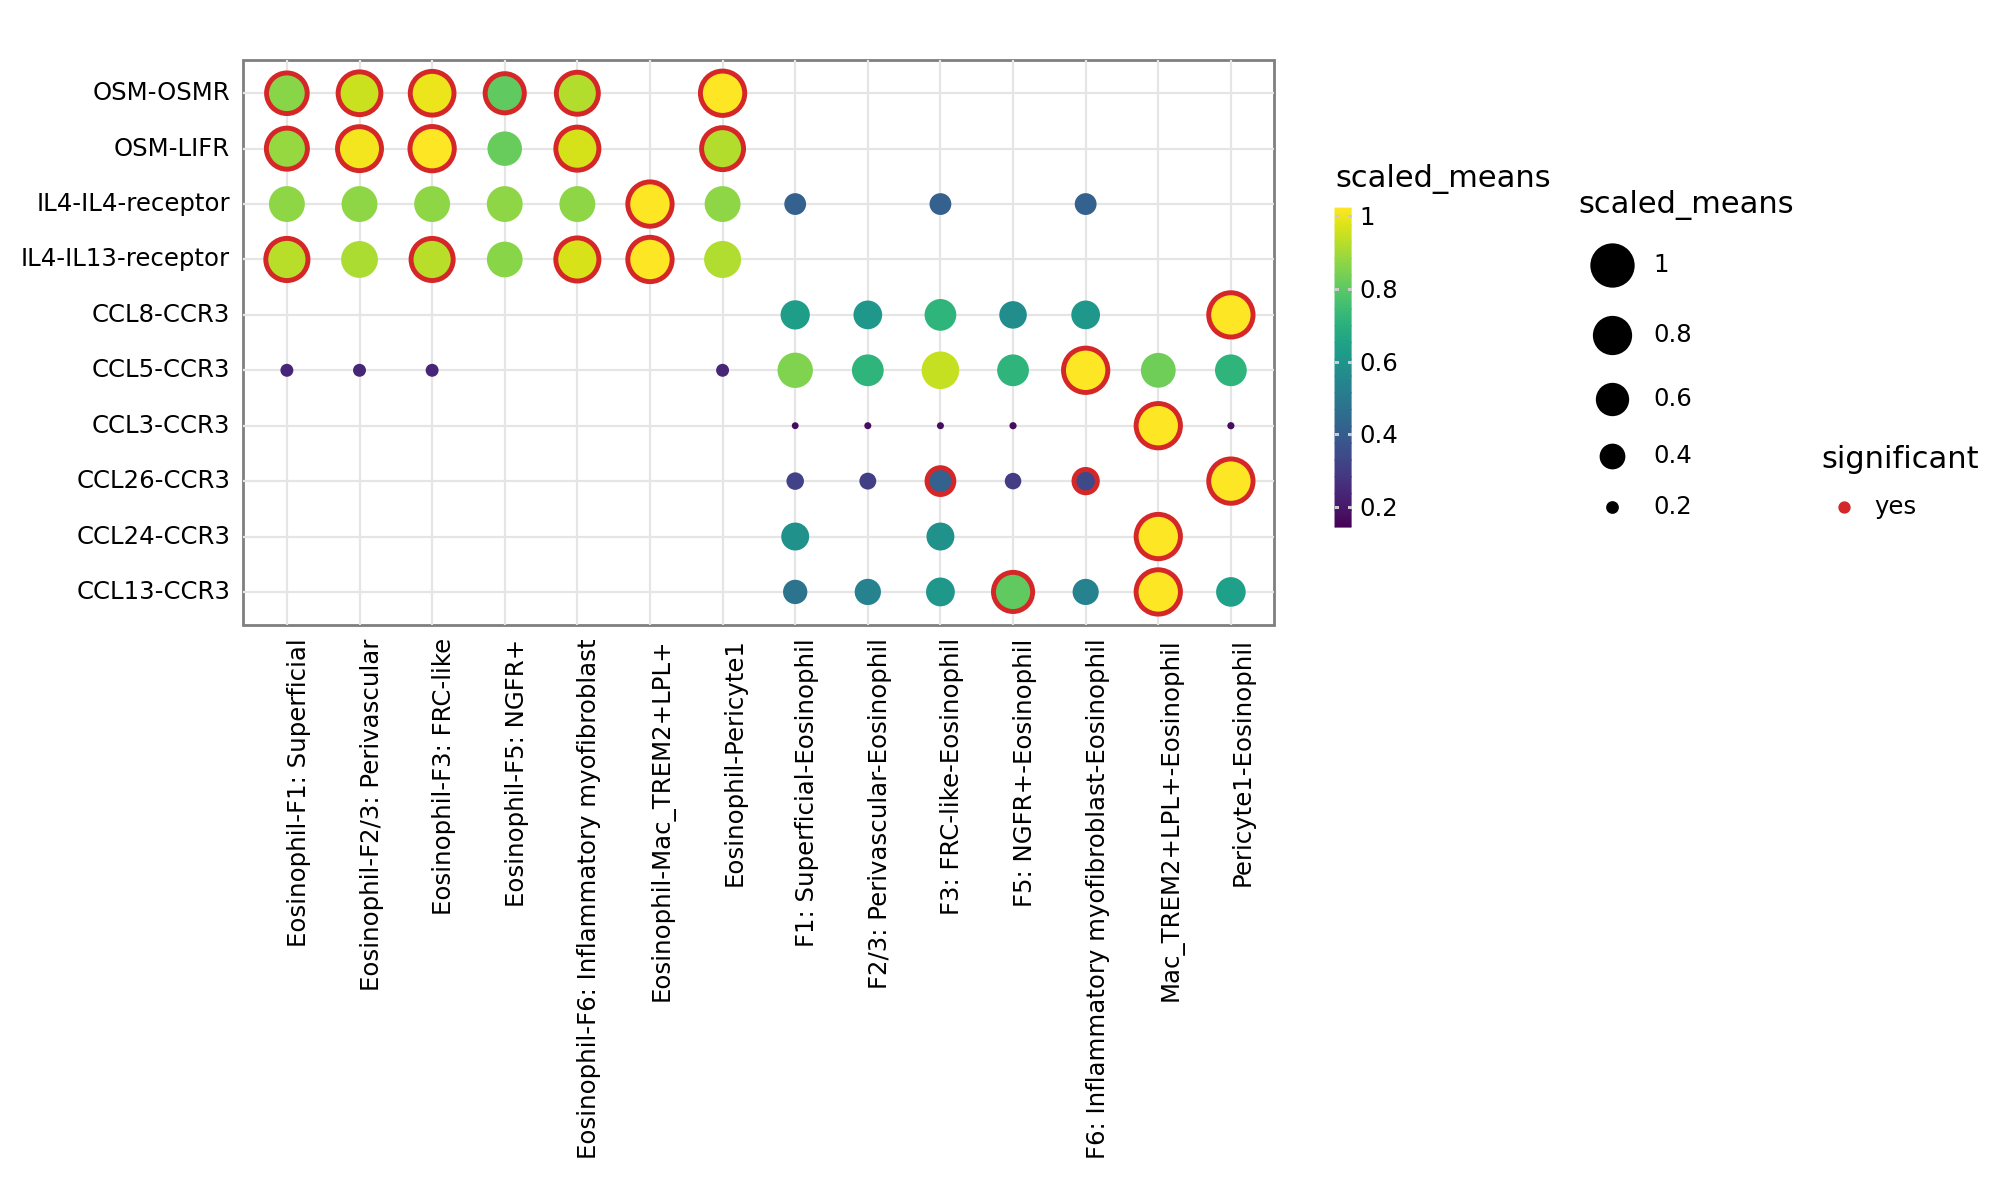

<Figure Size: (1000 x 600)>

In [12]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Eosinophil",
    cell_type2= KEEP,
     genes = [  "CCR3", "IL4", "OSM"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(10, 6),
)

